This file demonstrates and tests the `tile.py` `tile_sampler` function, which returns all cropfield polygons in a randomly selected tile. This may be beneficial for trying out functions in this repo on a smaller scale.

In [ ]:
def tile_sampler(gdf, tile_column, area_column, no_tiles, seed):
    """
        This function returns all polygons in randomly selected tiles. Tile selection probability is cropland area weighted.

        Arguments: 
        gdf : Geodataframe
        tile_column : Name of column with tile identifier numbers
        area_column : Name if column with crop polygon area values
        no_tiles : Number of tiles to be sampled 
        seed : Seed value for reproducibility

        Required packages: numpy
        
        Other relevant packages: geopandas and pandas (geodataframe creation and loading), os (directory navigation)
    """
    
    if seed is not None:
        np.random.seed(seed)

    tile_weights = gdf.groupby(tile_column)[area_column].sum() 
    tile_weights = tile_weights / tile_weights.sum()
    
    if no_tiles > len(tile_weights): 
        raise ValueError(f"Sample size is greater than total number of tiles.")

    tile_sample = np.random.choice(
        tile_weights.index, 
        size = no_tiles, 
        replace = False, 
        p = tile_weights.values
    )

    return gdf[gdf[tile_column].isin(tile_sample)]

SAMPLE USAGE:

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os

In [ ]:
print(os.getcwd())
os.chdir(r'C:\Users\solan\OneDrive\Desktop\IntrotoPython\FinalProj\cropfield-polygonization') # Change path to personal path to project

# Read File
zambia_shp = gpd.read_parquet(r'zambia_2023_attributed.parquet')

In [97]:
test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)

<Axes: >

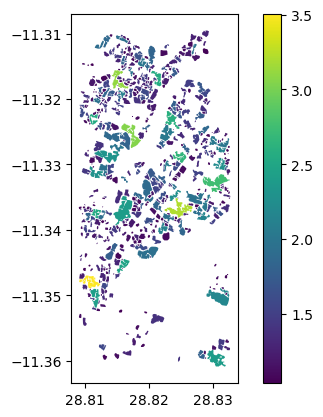

In [100]:
test_poly.head(600).plot(column="shape_index", cmap="viridis", legend=True)